In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches_path = "../data/matches_1930_2022.csv"

df = pd.read_csv(matches_path)

In [6]:
matches = df[["home_team", "away_team", "Year", "home_score", "away_score"]].copy()

home_matches = matches[[
    "home_team",
    "away_team",
    "Year",
    "home_score",
    "away_score"
]].copy()

home_matches = home_matches.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "Year": "year",
    "home_score": "goals_for",
    "away_score": "goals_against"
})

home_matches.head()

,team,opponent,year,goals_for,goals_against
0,Argentina,France,2022,3,3
1,Croatia,Morocco,2022,2,1
2,France,Morocco,2022,2,0
3,Argentina,Croatia,2022,3,0
4,Morocco,Portugal,2022,1,0


In [7]:
away_matches = matches[[
    "away_team",
    "home_team",
    "Year",
    "away_score",
    "home_score"
]].copy()

away_matches = away_matches.rename(columns={
    "away_team": "team",
    "home_team": "opponent",
    "Year": "year",
    "away_score": "goals_for",
    "home_score": "goals_against"
})

away_matches.head()

,team,opponent,year,goals_for,goals_against
0,France,Argentina,2022,3,3
1,Morocco,Croatia,2022,1,2
2,Morocco,France,2022,0,2
3,Croatia,Argentina,2022,0,3
4,Portugal,Morocco,2022,0,1


In [8]:
team_matches = pd.concat([home_matches, away_matches], ignore_index=True)

team_matches.head()

,team,opponent,year,goals_for,goals_against
0,Argentina,France,2022,3,3
1,Croatia,Morocco,2022,2,1
2,France,Morocco,2022,2,0
3,Argentina,Croatia,2022,3,0
4,Morocco,Portugal,2022,1,0


In [9]:
def get_match_result(row):
    if row["goals_for"] > row["goals_against"]:
        return "W"
    elif row["goals_for"] == row["goals_against"]:
        return "D"
    else:
        return "L"


team_matches["result"] = team_matches.apply(get_match_result, axis=1)

team_matches.head()

,team,opponent,year,goals_for,goals_against,result
0,Argentina,France,2022,3,3,D
1,Croatia,Morocco,2022,2,1,W
2,France,Morocco,2022,2,0,W
3,Argentina,Croatia,2022,3,0,W
4,Morocco,Portugal,2022,1,0,W


In [10]:
team_summary = (
    team_matches
    .groupby(["team", "year", "result"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

team_summary.head()

result,team,year,D,L,W
0,Algeria,1982,0,1,2
1,Algeria,1986,1,2,0
2,Algeria,2010,1,2,0
3,Algeria,2014,1,2,1
4,Angola,2006,2,1,0


In [11]:
for col in ["W", "D", "L"]:
    if col not in team_summary.columns:
        team_summary[col] = 0

team_summary["total_matches"] = (
    team_summary["W"] +
    team_summary["D"] +
    team_summary["L"]
)

team_summary = team_summary.rename(columns={
    "W": "win_matches",
    "D": "draw_matches",
    "L": "lost_matches"
})

team_summary = team_summary[[
    "team",
    "year",
    "total_matches",
    "win_matches",
    "draw_matches",
    "lost_matches"
]]

team_summary = team_summary.sort_values(
    ["year", "total_matches", "win_matches"],
    ascending=[False, False, False]
).reset_index(drop=True)

team_summary

result,team,year,total_matches,win_matches,draw_matches,lost_matches
0,France,2022,7,5,1,1
1,Argentina,2022,7,4,2,1
2,Morocco,2022,7,3,2,2
3,Croatia,2022,7,2,4,1
4,Brazil,2022,5,3,1,1
...,...,...,...,...,...,...
484,Paraguay,1930,2,1,0,1
485,Romania,1930,2,1,0,1
486,Belgium,1930,2,0,0,2
487,Bolivia,1930,2,0,0,2


In [12]:
team_summary["total_point"] = (
    team_summary["win_matches"] * 3 +
    team_summary["draw_matches"] * 1 +
    team_summary["lost_matches"] * 0
)

team_summary["point_per_match"] = (
    team_summary["total_point"] / team_summary["total_matches"]
).round(2)

team_summary

result,team,year,total_matches,win_matches,draw_matches,lost_matches,total_point,point_per_match
0,France,2022,7,5,1,1,16,2.29
1,Argentina,2022,7,4,2,1,14,2.00
2,Morocco,2022,7,3,2,2,11,1.57
3,Croatia,2022,7,2,4,1,10,1.43
4,Brazil,2022,5,3,1,1,10,2.00
...,...,...,...,...,...,...,...,...
484,Paraguay,1930,2,1,0,1,3,1.50
485,Romania,1930,2,1,0,1,3,1.50
486,Belgium,1930,2,0,0,2,0,0.00
487,Bolivia,1930,2,0,0,2,0,0.00


In [13]:
team_summary.isna().sum()

result
team               0
year               0
total_matches      0
win_matches        0
draw_matches       0
lost_matches       0
total_point        0
point_per_match    0
dtype: int64

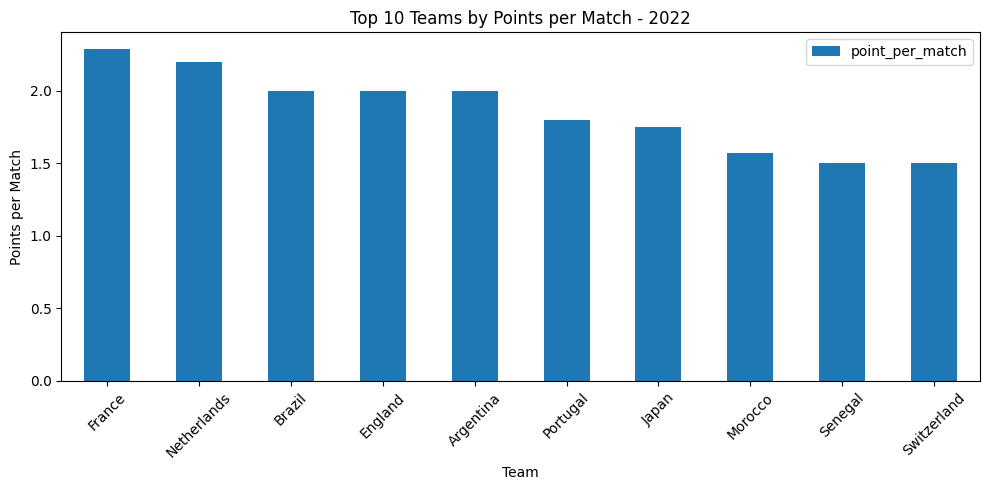

In [14]:
latest_year = team_summary["year"].max()

latest_year_summary = team_summary[
    team_summary["year"] == latest_year
].sort_values("point_per_match", ascending=False)

top_10_latest = latest_year_summary.head(10)

top_10_latest.plot(
    x="team",
    y="point_per_match",
    kind="bar",
    figsize=(10, 5)
)

plt.title(f"Top 10 Teams by Points per Match - {latest_year}")
plt.xlabel("Team")
plt.ylabel("Points per Match")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()